<a href="https://colab.research.google.com/github/1br4him858/Data-Analysis-project-/blob/main/WHO_Health_Project_Cells.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Data Analysis & Machine Learning Project

##  Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


##  Step 2: Upload Dataset

In [2]:
from google.colab import files
uploaded = files.upload()


Saving GHE_FULL_DD.csv to GHE_FULL_DD.csv


##  Step 3: Load Dataset

In [3]:
file_name = 'GHE_FULL_DD.csv'

df = pd.read_csv(file_name)

print(df.head())


  DIM_COUNTRY_CODE  DIM_YEAR_CODE       DIM_GHECAUSE_TITLE DIM_SEX_CODE  \
0              AFG           2021                 Syphilis         BTSX   
1              AFG           2021           Genital herpes         BTSX   
2              AFG           2021               Diphtheria         BTSX   
3              AFG           2021  African trypanosomiasis         BTSX   
4              AFG           2021                   Dengue         BTSX   

   VAL_DTHS_RATE100K_NUMERIC  
0                       1.46  
1                       0.00  
2                       0.11  
3                       0.00  
4                       0.00  


##  Step 4: Explore Dataset

In [4]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())


(24522, 5)
Index(['DIM_COUNTRY_CODE', 'DIM_YEAR_CODE', 'DIM_GHECAUSE_TITLE',
       'DIM_SEX_CODE', 'VAL_DTHS_RATE100K_NUMERIC'],
      dtype='object')
DIM_COUNTRY_CODE             0
DIM_YEAR_CODE                0
DIM_GHECAUSE_TITLE           0
DIM_SEX_CODE                 0
VAL_DTHS_RATE100K_NUMERIC    0
dtype: int64


##  Step 5: Data Cleaning

In [5]:
df = df.dropna()
df = df.drop_duplicates()

print(df.shape)


(24522, 5)


##  Step 6: Select Important Columns

In [6]:
important_columns = [
    'DIM_COUNTRY_CODE',
    'DIM_YEAR_CODE',
    'DIM_GHECAUSE_TITLE',
    'DIM_SEX_CODE',
    'VAL_DTHS_RATE100K_NUMERIC'
]

df = df[important_columns]

df = df.rename(columns={
    'DIM_COUNTRY_CODE': 'country',
    'DIM_YEAR_CODE': 'year',
    'DIM_GHECAUSE_TITLE': 'cause',
    'DIM_SEX_CODE': 'sex',
    'VAL_DTHS_RATE100K_NUMERIC': 'deaths'
})

print(df.head())


  country  year                    cause   sex  deaths
0     AFG  2021                 Syphilis  BTSX    1.46
1     AFG  2021           Genital herpes  BTSX    0.00
2     AFG  2021               Diphtheria  BTSX    0.11
3     AFG  2021  African trypanosomiasis  BTSX    0.00
4     AFG  2021                   Dengue  BTSX    0.00


##  Step 7: Filtering

In [7]:
print(df['country'].unique()[:20])

egypt_df = df[df['country'] == 'EGY']
print(egypt_df.head())

print(df['sex'].unique())

male_df = df[df['sex'] == 'MLE']
print(male_df.head())


['AFG' 'AGO' 'ALB' 'ARE' 'ARG' 'ARM' 'ATG' 'AUS' 'AUT' 'AZE' 'BDI' 'BEL'
 'BEN' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS' 'BIH' 'BLR']
     country  year              cause   sex  deaths
6566     EGY  2021          Chlamydia  BTSX    0.00
6567     EGY  2021     Trichomoniasis  BTSX    0.00
6568     EGY  2021            Measles  BTSX    0.01
6569     EGY  2021         Meningitis  BTSX    0.39
6570     EGY  2021  Acute hepatitis E  BTSX    0.02
['BTSX']
Empty DataFrame
Columns: [country, year, cause, sex, deaths]
Index: []


##  Step 8: Grouping & Aggregation

In [8]:
cause_deaths = df.groupby('cause')['deaths'].sum().sort_values(ascending=False)

print(cause_deaths.head(10))

avg_deaths_sex = df.groupby('sex')['deaths'].mean()

print(avg_deaths_sex)

yearly_deaths = df.groupby('year')['deaths'].sum()

print(yearly_deaths)


cause
Ischaemic heart disease                  21302.02
COVID-19                                 20294.23
Stroke                                   14069.39
Lower respiratory infections              6729.54
Diabetes mellitus                         5055.78
Chronic obstructive pulmonary disease     4075.28
Hypertensive heart disease                3979.18
Kidney diseases                           3817.97
Alzheimer disease and other dementias     3711.33
Tuberculosis                              3515.97
Name: deaths, dtype: float64
sex
BTSX    5.820255
Name: deaths, dtype: float64
year
2021    142724.3
Name: deaths, dtype: float64


##  Step 9: Visualizations

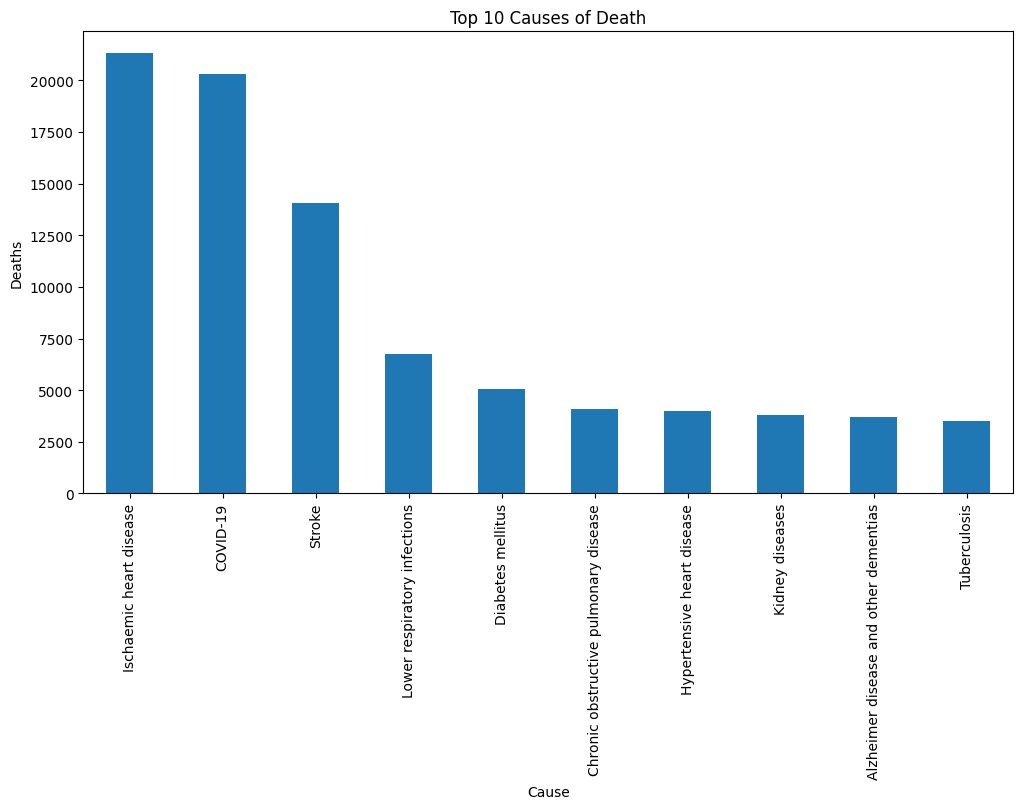

In [9]:
plt.figure(figsize=(12,6))
cause_deaths.head(10).plot(kind='bar')
plt.title('Top 10 Causes of Death')
plt.xlabel('Cause')
plt.ylabel('Deaths')
plt.show()


##  Step 10: Insights

In [12]:
most_dangerous = cause_deaths.idxmax()
print('Most Dangerous Cause of Death:', most_dangerous)

highest_avg = avg_deaths_sex.idxmax()
print('Highest Average Deaths:', highest_avg)

print('\nTop 5 Causes of Death:')
print(cause_deaths.head(5))

print('\nLeast Dangerous Causes:')
print(cause_deaths.tail(5))

highest_year = yearly_deaths.idxmax()
print('\nYear With Highest Deaths:', highest_year)

print('\nTotal Deaths:', df['deaths'].sum())

print('\nAverage Deaths:', df['deaths'].mean())


Most Dangerous Cause of Death: Ischaemic heart disease
Highest Average Deaths: BTSX

Top 5 Causes of Death:
cause
Ischaemic heart disease         21302.02
COVID-19                        20294.23
Stroke                          14069.39
Lower respiratory infections     6729.54
Diabetes mellitus                5055.78
Name: deaths, dtype: float64

Least Dangerous Causes:
cause
Lymphatic filariasis             0.0
Trichomoniasis                   0.0
Trachoma                         0.0
Uncorrected refractive errors    0.0
Trichuriasis                     0.0
Name: deaths, dtype: float64

Year With Highest Deaths: 2021

Total Deaths: 142724.3

Average Deaths: 5.820255280972188


##  Step 11: Additional Insights

In [13]:
country_deaths = df.groupby('country')['deaths'].sum().sort_values(ascending=False)

print(country_deaths.head(10))


country
BGR    2026.73
SRB    1836.08
LVA    1679.63
BIH    1646.05
ROU    1592.20
LTU    1586.04
UKR    1581.62
MDA    1562.47
RUS    1478.77
GEO    1473.06
Name: deaths, dtype: float64


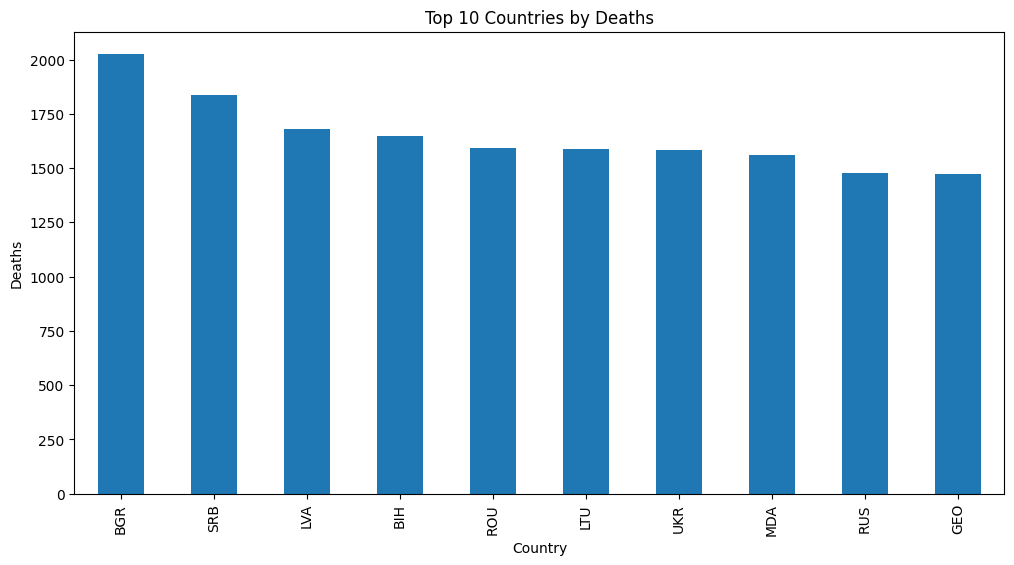

In [14]:
plt.figure(figsize=(12,6))
country_deaths.head(10).plot(kind='bar')
plt.title('Top 10 Countries by Deaths')
plt.xlabel('Country')
plt.ylabel('Deaths')
plt.show()


##  Step 12: Encode Categorical Columns

In [15]:
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le


##  Step 13: Features & Target

In [16]:
X = df.drop('deaths', axis=1)

y = df['deaths']


##  Step 14: Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


##  Step 15: Linear Regression

In [18]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)


##  Step 16: Linear Regression Evaluation

In [19]:
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print('Linear Regression Evaluation')
print('MAE:', lr_mae)
print('RMSE:', lr_rmse)
print('R2 Score:', lr_r2)


Linear Regression Evaluation
MAE: 8.647133522335842
RMSE: 24.366721650677647
R2 Score: 0.0005650404684452992


##  Step 17: Random Forest

In [20]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)


##  Step 18: Random Forest Evaluation

In [21]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print('Random Forest Evaluation')
print('MAE:', rf_mae)
print('RMSE:', rf_rmse)
print('R2 Score:', rf_r2)


Random Forest Evaluation
MAE: 4.829501997961264
RMSE: 19.575115929399374
R2 Score: 0.3549861832051764


##  Step 19: Compare Models

In [22]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})

print(comparison)


               Model       MAE       RMSE  R2 Score
0  Linear Regression  8.647134  24.366722  0.000565
1      Random Forest  4.829502  19.575116  0.354986
